# Journal-extension robustness audit

## tl;dr

- The current-canopy signal survives fixed Logistic, Random Forest, and XGBoost expanding-window models.
- For current-only, random-CV versus expanding-window macro within-year AP lift is 0.176 versus 0.177; the pooled comparison is 0.187 versus 0.179.
- Trajectory adds a small supported increment for Logistic and Random Forest, but not XGBoost. OISST and CUTI/BEUTI show no supported positive increment in any family.
- Current-only event recall is 8.5%, 17.7%, 32.0%, and 43.2% at 5%, 10%, 20%, and 30% annual monitoring budgets.
- Across nine outcome/eligibility combinations, current-only macro within-year AP lift ranges from 0.153 to 0.191; the OISST increment is non-positive in all nine.

This is a pilot-informed reviewer-robustness analysis, not preregistered or independent confirmation.

## Context & Methods

The notebook audits four additions to the locked 165-cell analysis: evaluation protocol/aggregation, model-family robustness, decision-budget curves, and label/eligibility sensitivity.

### Key Assumptions

- Operational estimates use 2005–2024 expanding-window predictions and macro within-year AP lift over annual prevalence.
- Repeated random cell-year CV intentionally permits future-year and repeated-cell information in training; it is an optimism diagnostic, not a deployment estimate.
- Logistic, Random Forest, and XGBoost use fixed prespecified specifications. This is a robustness check, not a hyperparameter competition.
- Decline thresholds are operational labels, not validated ecological-collapse thresholds.
- NOAA features are public environmental proxies; their predictive increment is not a causal test of environmental importance.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'outputs').exists() and (ROOT.parent / 'outputs').exists():
    ROOT = ROOT.parent
RUN = ROOT / 'outputs/experiments/20260814_journal_extension_v1'
assert (RUN / 'manifest.json').exists()

quality = pd.read_csv(RUN / 'data_quality_profile.csv')
protocol = pd.read_csv(RUN / 'protocol_comparison.csv')
model_summary = pd.read_csv(RUN / 'model_family_summary.csv')
increments = pd.read_csv(RUN / 'model_family_increment_summary.csv')
budget = pd.read_csv(RUN / 'budget_summary.csv')
sensitivity = pd.read_csv(RUN / 'sensitivity_model_metrics.csv')
sensitivity_increments = pd.read_csv(RUN / 'sensitivity_increment_summary.csv')
validation = pd.read_csv(RUN / 'validation_recheck.csv')
decision = json.loads((RUN / 'decision.json').read_text(encoding='utf-8'))

assert validation['passed'].all()
assert decision['classification'].startswith('pilot-informed')
print('Loaded', RUN)
print('Validation checks passed:', int(validation['passed'].sum()), '/', len(validation))

Loaded /Users/miso/Documents/Codex/2026-06-11/create-an-initial-github-repository-structure/kelp-decline-early-warning/outputs/experiments/20260814_journal_extension_v1
Validation checks passed: 28 / 28


## Data

In [2]:
quality

,check,value
0,panel_rows,6930
1,panel_cells,165
2,panel_year_min,1984
3,panel_year_max,2025
4,panel_duplicate_keys,0
5,environment_rows,6930
6,environment_duplicate_keys,0
7,merged_rows,6930
8,primary_eligible_rows,4618
9,primary_eligible_cells,165


The intended grain is one cell-year. The panel has 165 unique cells and 6,930 unique cell-year rows. The full OISST evaluation contains 2,614 eligible forecast rows; the supported CUTI/BEUTI domain contains 1,698.

## Results

### 1. Evaluation protocol and aggregation

In [3]:
protocol.loc[protocol['domain'].eq('full_oisst_domain'), [
    'feature_label', 'random_pooled_mean', 'expanding_pooled',
    'random_macro_within_year_mean', 'expanding_macro_within_year',
    'random_minus_expanding_pooled',
    'random_minus_expanding_macro_within_year'
]].round(4)

,feature_label,random_pooled_mean,expanding_pooled,random_macro_within_year_mean,expanding_macro_within_year,random_minus_expanding_pooled,random_minus_expanding_macro_within_year
0,Current,0.1870,0.1794,0.1761,0.1765,0.0076,-0.0005
1,Current + trajectory,0.1999,0.1850,0.2053,0.2004,0.0149,0.0048
2,Current + trajectory + OISST,0.1950,0.1582,0.1911,0.1779,0.0368,0.0132


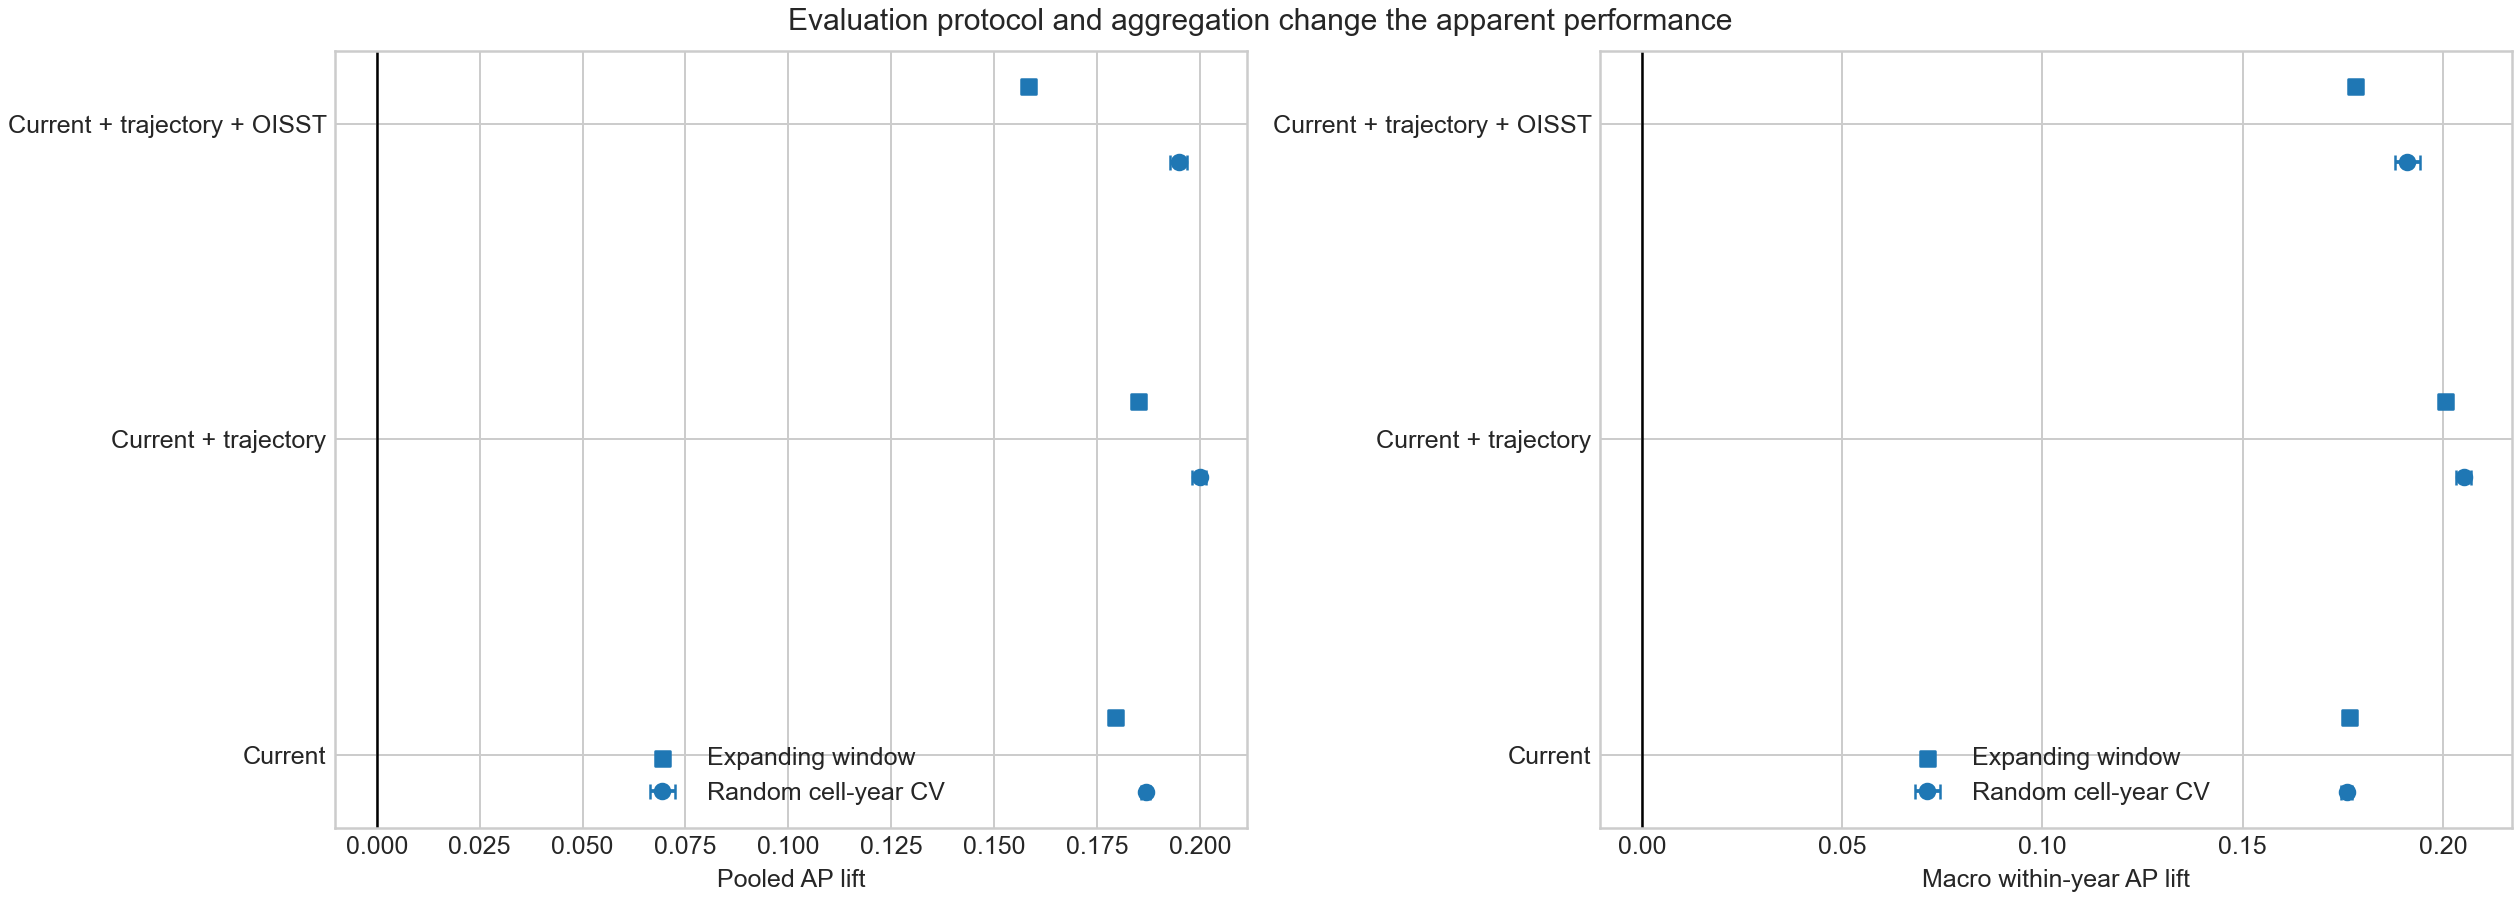

In [4]:
display(Image(filename=str(RUN / 'figure_01_protocol_comparison.png')))

Random CV does not inflate every metric equally. The current-only macro within-year estimate is nearly unchanged, while pooled estimates and richer information blocks show larger optimism. The paper should therefore report the exact protocol/metric rather than claim a universal random-split inflation factor.

### 2. Fixed model-family robustness

In [5]:
increments.loc[
    (increments['domain'].eq('full_oisst_domain') & increments['comparison'].isin(['trajectory_minus_current', 'oisst_minus_trajectory']))
    | (increments['domain'].eq('upwelling_supported_domain') & increments['comparison'].eq('cuti_beuti_minus_oisst')),
    ['model_label', 'comparison', 'estimate', 'ci_low', 'ci_high']
].round(4)

,model_label,comparison,estimate,ci_low,ci_high
0,Logistic,trajectory_minus_current,0.0239,0.0045,0.0442
1,Logistic,oisst_minus_trajectory,-0.0225,-0.0543,0.0048
2,Random forest,trajectory_minus_current,0.0236,0.0095,0.0378
3,Random forest,oisst_minus_trajectory,0.0060,-0.0202,0.0301
4,XGBoost,trajectory_minus_current,0.0057,-0.0069,0.0187
5,XGBoost,oisst_minus_trajectory,0.0081,-0.0250,0.0419
8,Logistic,cuti_beuti_minus_oisst,-0.0031,-0.0280,0.0265
11,Random forest,cuti_beuti_minus_oisst,-0.0038,-0.0418,0.0284
14,XGBoost,cuti_beuti_minus_oisst,0.0037,-0.0407,0.0514


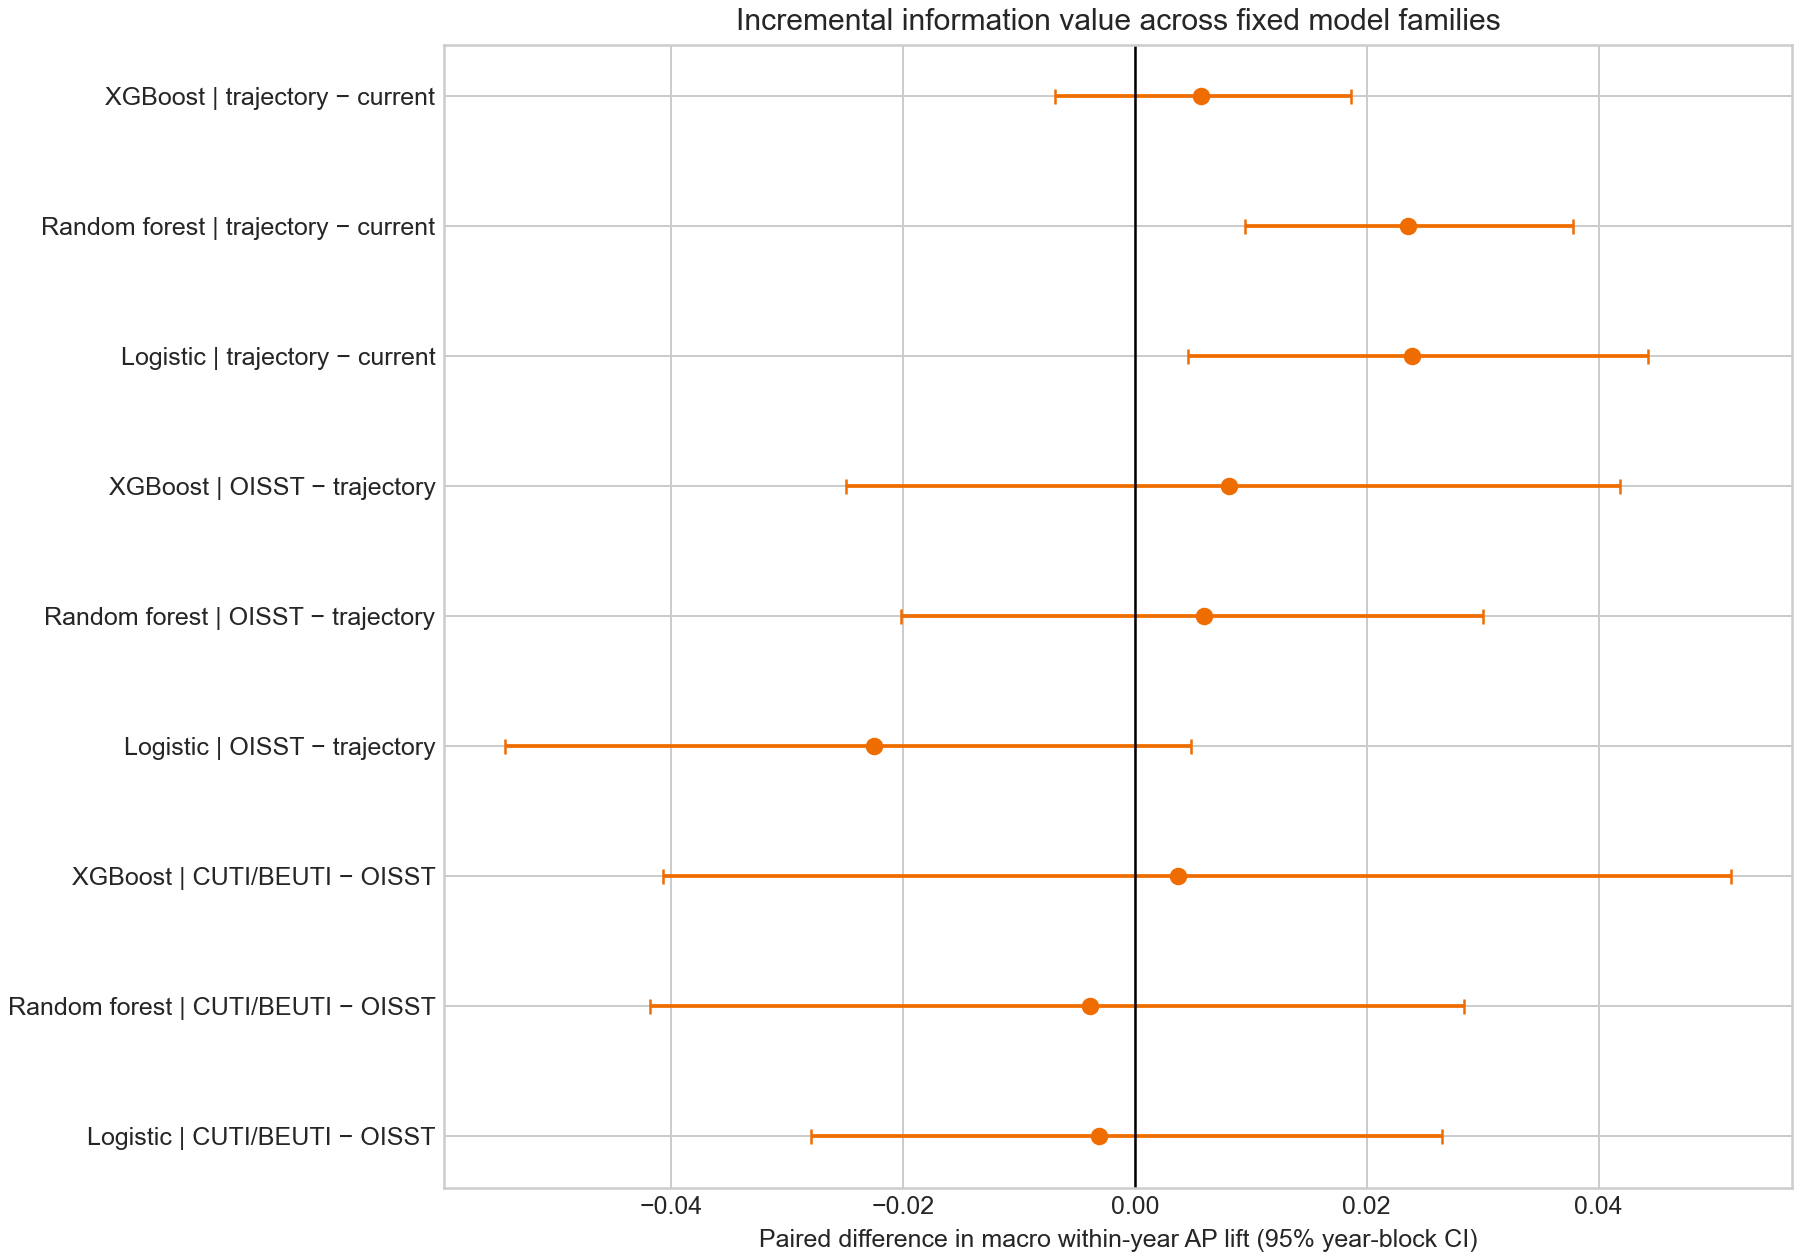

In [6]:
display(Image(filename=str(RUN / 'figure_02_model_family_increments.png')))

The defensible statement is asymmetric: the current-state ranking signal is model-robust; trajectory has small and partly model-dependent incremental value; neither OISST nor CUTI/BEUTI has supported positive incremental value in any tested model family.

### 3. Monitoring-budget trade-off

In [7]:
budget.loc[
    budget['domain'].eq('full_oisst_domain') & budget['model_family'].eq('logistic'),
    ['feature_set', 'budget_fraction', 'micro_recall', 'recall_ci_low', 'recall_ci_high', 'micro_precision']
].round(4)

,feature_set,budget_fraction,micro_recall,recall_ci_low,recall_ci_high,micro_precision
0,current_only,0.05,0.0853,0.0729,0.1023,0.6187
1,current_only,0.10,0.1766,0.1539,0.2070,0.6593
2,current_only,0.20,0.3204,0.2871,0.3649,0.6094
3,current_only,0.30,0.4315,0.4016,0.4717,0.5479
4,current_plus_trajectory,0.05,0.0903,0.0763,0.1105,0.6547
5,current_plus_trajectory,0.10,0.1825,0.1595,0.2148,0.6815
6,current_plus_trajectory,0.20,0.3234,0.2872,0.3754,0.6151
7,current_plus_trajectory,0.30,0.4425,0.4112,0.4874,0.5617
8,trajectory_plus_oisst,0.05,0.0863,0.0742,0.1026,0.6259
9,trajectory_plus_oisst,0.10,0.1736,0.1517,0.2038,0.6481


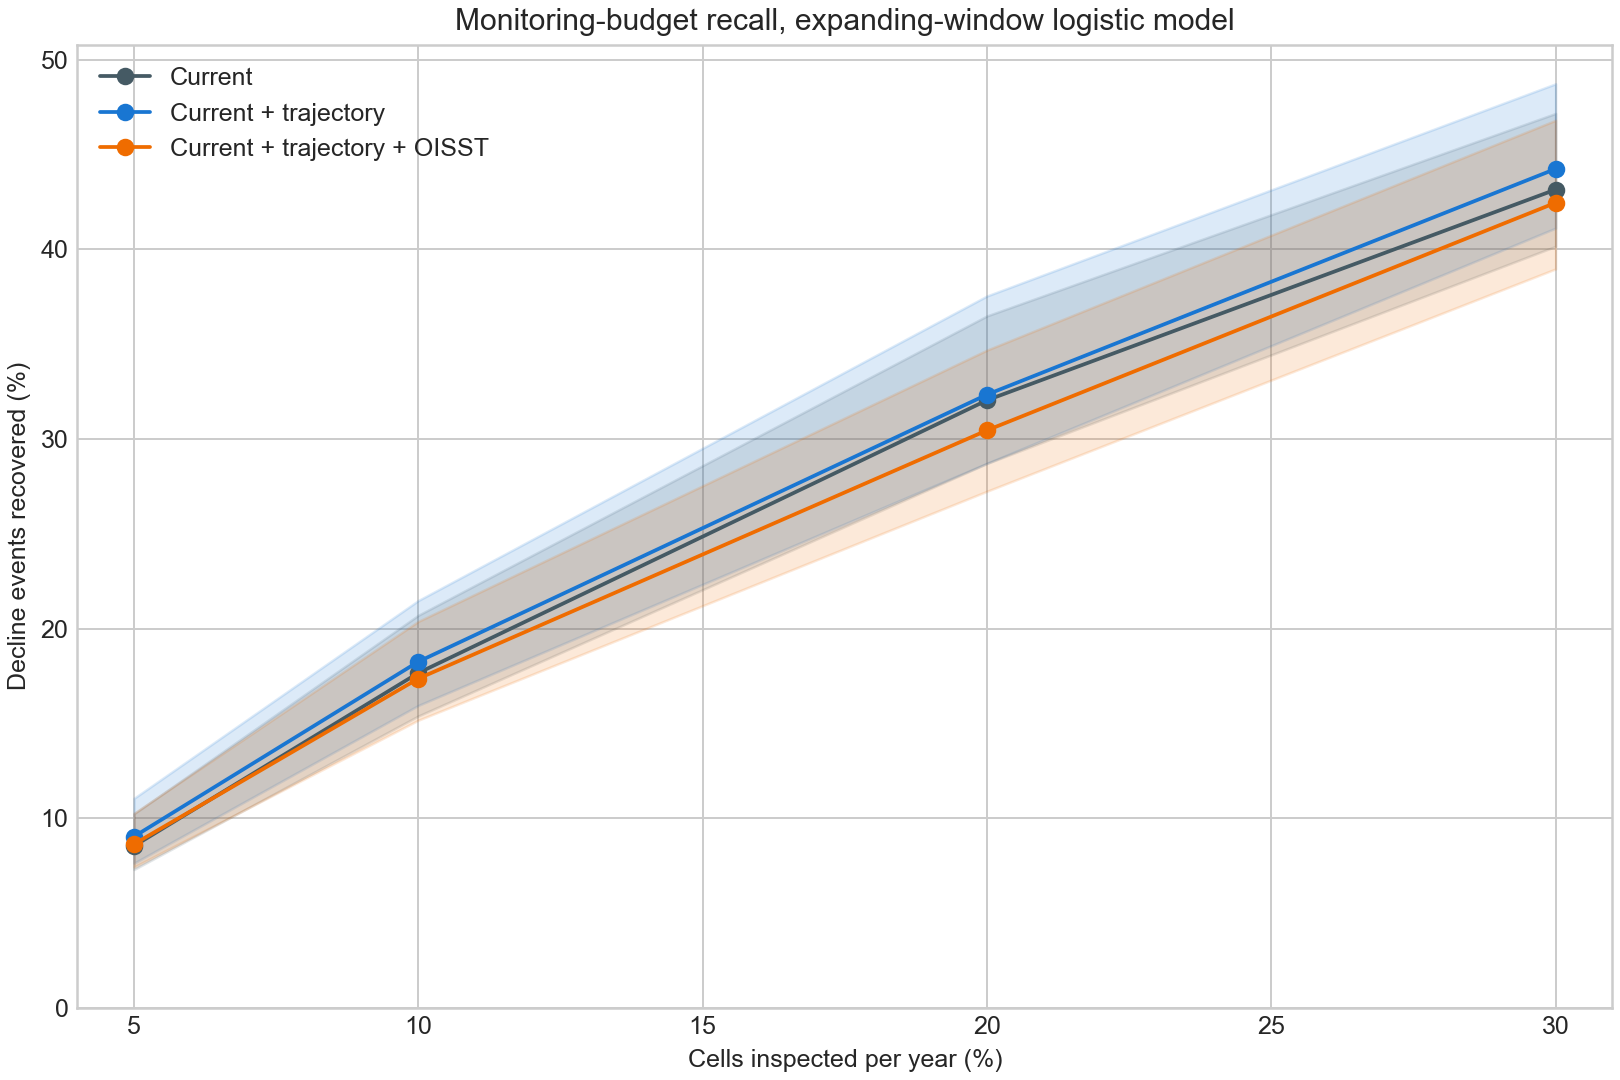

In [8]:
display(Image(filename=str(RUN / 'figure_03_budget_recall_curve.png')))

Trajectory changes current-only recall by less than one percentage point at 5%, 10%, and 20% budgets, and by about one point at 30%. OISST is lower than trajectory at every plotted budget. The statistically detectable trajectory AP increment therefore has limited operational magnitude.

### 4. Outcome and eligibility sensitivity

In [9]:
sensitivity.loc[
    sensitivity['domain'].eq('full_oisst_domain') & sensitivity['feature_set'].eq('current_only'),
    ['decline_threshold', 'canopy_cutoff', 'n', 'events', 'prevalence', 'macro_within_year_ap_lift']
].sort_values(['decline_threshold', 'canopy_cutoff']).round(4)

,decline_threshold,canopy_cutoff,n,events,prevalence,macro_within_year_ap_lift
0,0.2,0.02,2808,1183,0.4213,0.1900
7,0.2,0.05,2614,1130,0.4323,0.1913
14,0.2,0.10,2385,1082,0.4537,0.1835
21,0.3,0.02,2808,1058,0.3768,0.1746
28,0.3,0.05,2614,1008,0.3856,0.1765
35,0.3,0.10,2385,967,0.4055,0.1703
42,0.4,0.02,2808,938,0.3340,0.1536
49,0.4,0.05,2614,888,0.3397,0.1572
56,0.4,0.10,2385,852,0.3572,0.1526


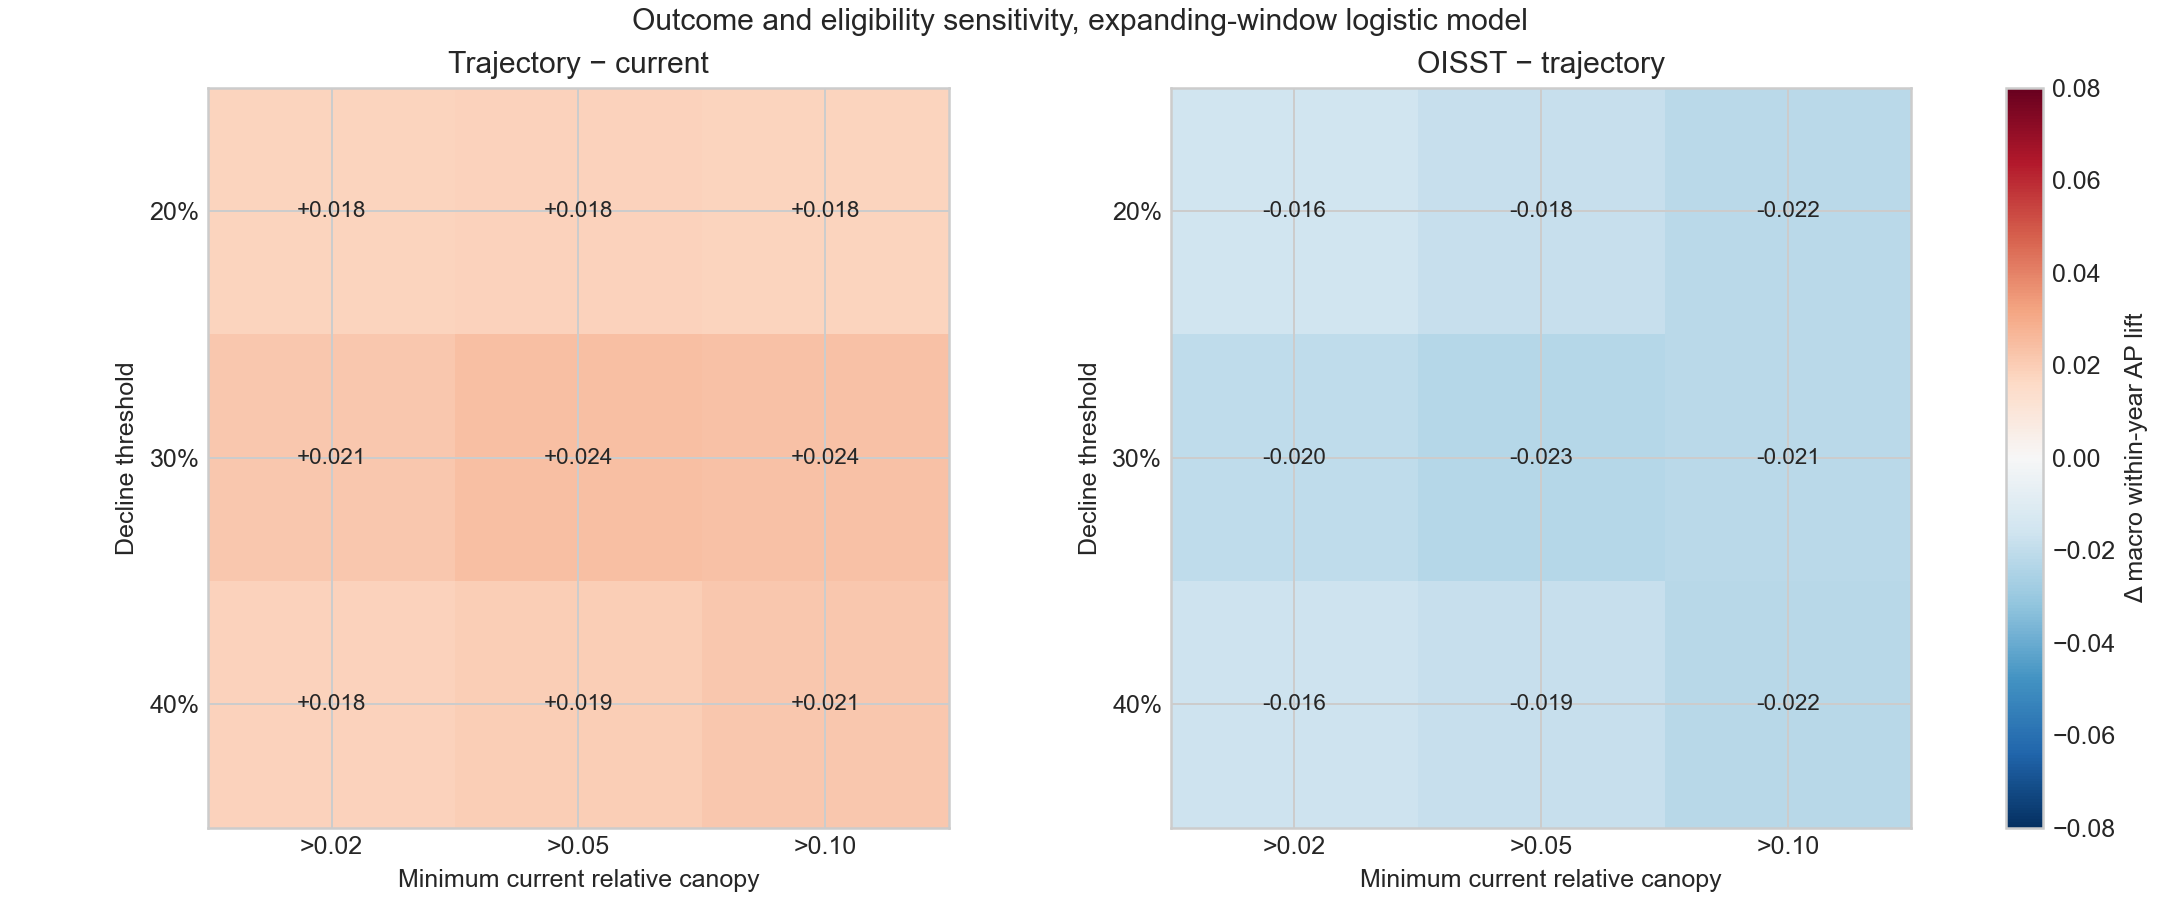

In [10]:
display(Image(filename=str(RUN / 'figure_04_threshold_canopy_sensitivity.png')))

The current-only ranking conclusion persists across all nine operational definitions. Trajectory remains positive in point estimate across all nine, but its confidence interval crosses zero in two 40% variants. OISST is negative in point estimate in all nine and never has a confidence interval excluding zero on the positive side.

## Takeaways

1. The strongest journal claim is the robust value of low-cost current-canopy information under deployment-realistic ranking evaluation.
2. Recent trajectory is a small secondary information source, not a large operational improvement.
3. The selected coarse NOAA proxies do not justify claims of additional predictive information after canopy history; this does not imply that environment is ecologically unimportant.
4. The paper should foreground validation design and marginal information value, then present kelp ecology as the application and variable rationale.
5. All headline numbers are independently recomputed in `validation_recheck.csv`; the overall assessment is `Share with caveats`.